### Lab 4.2: Trích xuất và Mô tả Đặc trưng Bất biến SIFT & SURF

#### Phần 0: Khởi tạo Notebook và Load Dữ liệu

Tương tự như Lab 4.1, chúng ta cần import các thư viện cốt lõi và tải về một số cặp ảnh mẫu. Để thấy được sức mạnh của SIFT/SURF, ta sẽ dùng 2 bức ảnh chụp cùng một vật thể nhưng ở góc độ, khoảng cách (tỷ lệ) và điều kiện ánh sáng khác nhau.

/content/CV_Labs/Lab_4_2


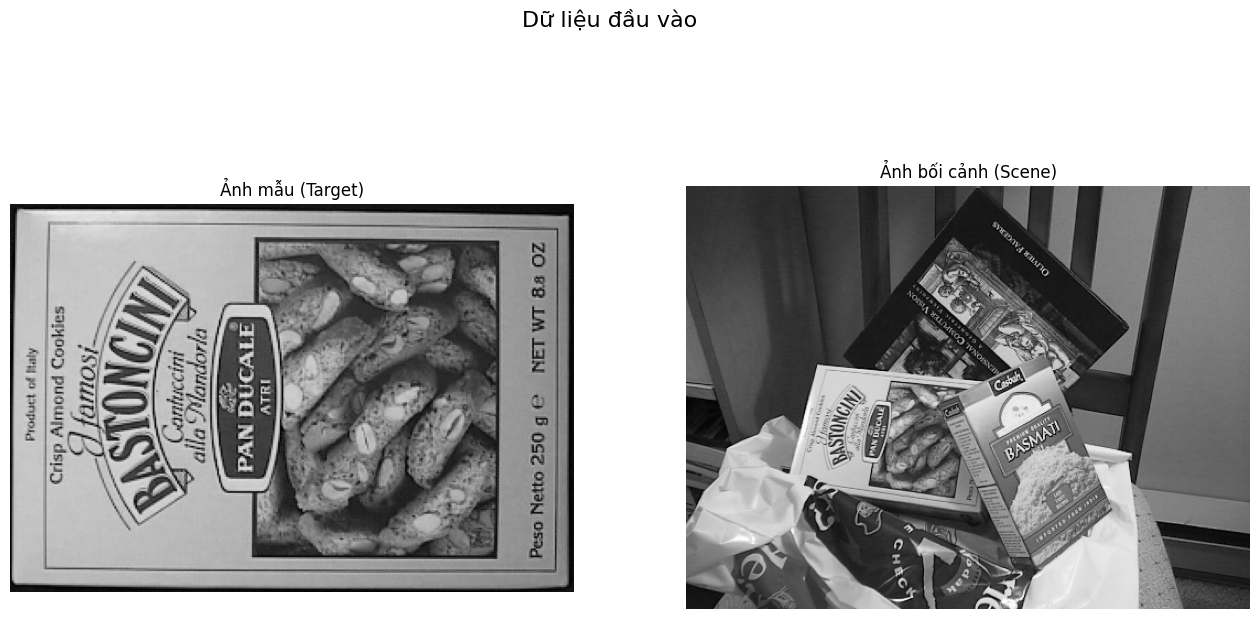

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from os.path import join

# Khai báo lại hàm phụ trợ hiển thị ảnh
def imshow_cv(title, img, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def imshow_multiple(title, images, titles, figsize=(16, 8)):
    fig, axs = plt.subplots(1, len(images), figsize=figsize)
    fig.suptitle(title, fontsize=16)
    for i, (img, t) in enumerate(zip(images, titles)):
        if len(img.shape) == 3:
            axs[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axs[i].imshow(img, cmap='gray')
        axs[i].set_title(t)
        axs[i].axis('off')
    plt.show()

# Tạo thư mục làm việc cho Lab 4.2
lab_path = "/content/CV_Labs/Lab_4_2/"
os.makedirs(lab_path, exist_ok=True)
%cd "{lab_path}"

# Tải cặp ảnh mẫu chứa cùng một đối tượng (ví dụ: biển báo giao thông hoặc ảnh sách)
# để test tính bất biến của đặc trưng
!wget -q -O target_object.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png"
!wget -q -O scene_image.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png"

img_target = cv2.imread('target_object.jpg')
img_scene = cv2.imread('scene_image.jpg')

# Hiển thị ảnh mẫu
imshow_multiple('Dữ liệu đầu vào', [img_target, img_scene], ['Ảnh mẫu (Target)', 'Ảnh bối cảnh (Scene)'])

#### Phần 1: Thuật toán SIFT ("Tiêu chuẩn vàng")

**Mục tiêu:** Thuật toán SIFT (Scale-Invariant Feature Transform) do David Lowe đề xuất là một trong những thuật toán mô tả đặc trưng mạnh mẽ nhất. Sinh viên sẽ thực hành trích xuất điểm đặc trưng (Keypoint) trải qua 4 bước: Dò tìm cực trị không gian tỷ lệ (Scale-space extrema), Định vị điểm, Gán hướng và Tạo vector mô tả 128 chiều.

**1.1 Dò tìm điểm đặc trưng (Keypoint Detection)**

OpenCV cung cấp sẵn lớp `cv2.SIFT_create()`. Chúng ta sẽ trích xuất keypoint và vẽ chúng lên ảnh. Việc sử dụng cờ `cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS` sẽ giúp vẽ các vòng tròn thể hiện cả **kích thước (scale)** và **hướng (orientation)** của từng điểm đặc trưng.

Số lượng Keypoint trên ảnh Target: 604
Số lượng Keypoint trên ảnh Scene: 969


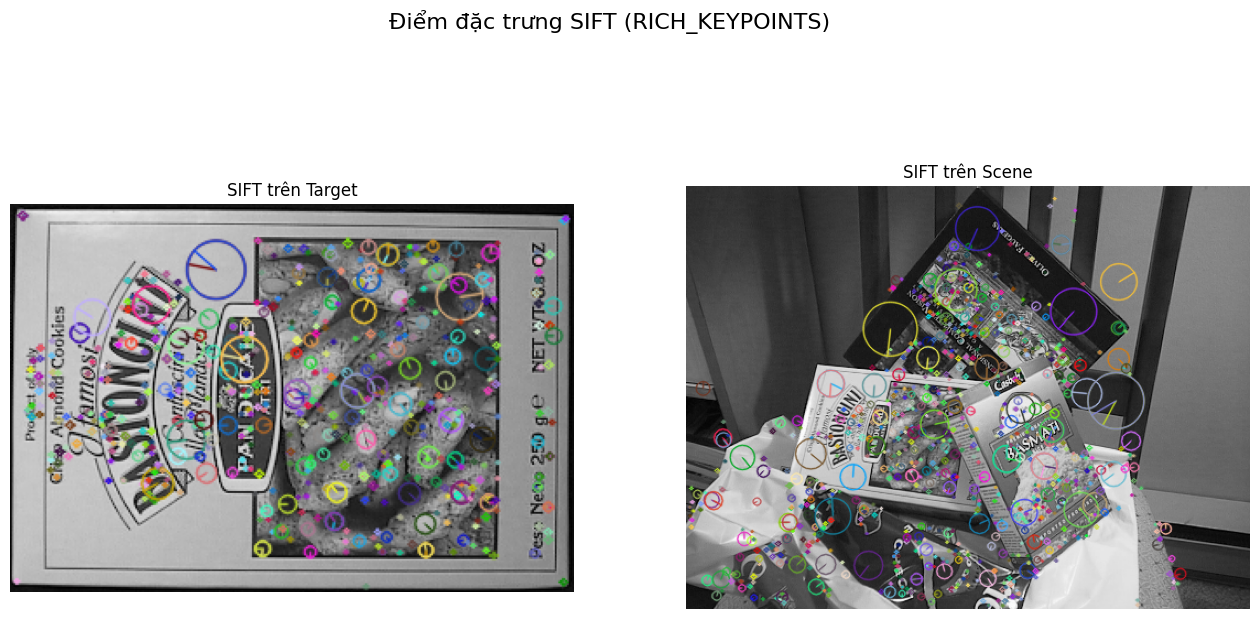

In [2]:
# Khởi tạo đối tượng SIFT
sift = cv2.SIFT_create()

# Chuyển ảnh sang thang độ xám (SIFT hoạt động trên ảnh xám)
gray_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2GRAY)
gray_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2GRAY)

# Tìm Keypoints và tính toán Descriptor cùng lúc
# Hàm trả về 2 biến: keypoints (chứa tọa độ, kích thước, góc) và descriptors (vector đặc trưng)
kp_target, des_target = sift.detectAndCompute(gray_target, None)
kp_scene, des_scene = sift.detectAndCompute(gray_scene, None)

print(f"Số lượng Keypoint trên ảnh Target: {len(kp_target)}")
print(f"Số lượng Keypoint trên ảnh Scene: {len(kp_scene)}")

# Vẽ keypoints với thông tin về Tỷ lệ và Hướng (vòng tròn và đường bán kính)
img_target_sift = cv2.drawKeypoints(img_target, kp_target, None,
                                    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_scene_sift = cv2.drawKeypoints(img_scene, kp_scene, None,
                                   flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

imshow_multiple('Điểm đặc trưng SIFT (RICH_KEYPOINTS)',
                [img_target_sift, img_scene_sift],
                ['SIFT trên Target', 'SIFT trên Scene'])

**1.2 Phân tích cấu trúc Descriptor của SIFT**

SIFT tạo ra bộ mô tả dựa trên lưới lân cận $16 \times 16$ pixel xung quanh keypoint, chia thành 16 ô (mỗi ô $4 \times 4$). Trong mỗi ô, thuật toán tính histogram gồm 8 hướng gradient. Do đó, vector kết quả có chiều dài là $16 \times 8 = 128$ chiều.

Kích thước ma trận Descriptor của ảnh Target: (604, 128)

Thông tin Keypoint #0:
 - Tọa độ (x, y): (3.4104702472686768, 216.3043975830078)
 - Tỷ lệ (kích thước vùng ảnh hưởng - size): 2.67
 - Hướng chính (angle): 278.23 độ

Vector mô tả SIFT của Keypoint #0 (128 chiều):
[  0.   0.   0.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.   0.
   1.  11.   1.   0.   0.   0.   0.   0.  27.  19.   0.   0.   0.   0.
   0.   0.  57.  11.  15.   0.   0.   0.   0.   0.   0.   8. 154.   2.
   0.   0.   0.   0.  18. 164.  33.   1.   0.   0.   0.   0. 164. 164.
   0.   0.   1.   0.   0.   0. 164.  56.  38.   4.   0.   0.   0.   0.
   0.   2. 164.  64.   0.   0.   0.   0.   1.  55. 154.  35.   2.   0.
   0.   0.  17.  43.   1.   6.   6.   0.   0.   0.  13.   4.  18.   2.
   0.   0.   0.   0.   0.   1. 164.  63.   0.   0.   0.   0.   0.   0.
 164.  37.   0.   0.   0.   0.   0.   0.   5.   4.   1.   0.   0.   0.
   0.   0.]


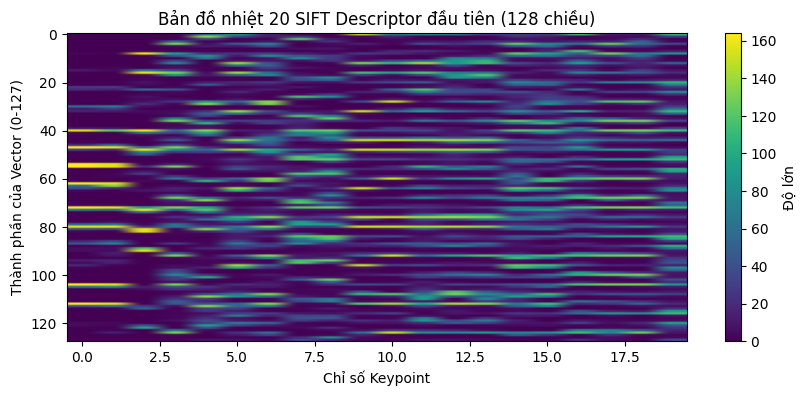

In [4]:
# Phân tích Descriptor của ảnh Target
print("Kích thước ma trận Descriptor của ảnh Target:", des_target.shape)

# Trích xuất thử thông tin của Keypoint đầu tiên
# Sửa lỗi: lấy phần tử index 0 của danh sách keypoints
first_kp = kp_target[0]
first_des = des_target[0]

print(f"\nThông tin Keypoint #0:")
print(f" - Tọa độ (x, y): {first_kp.pt}")
print(f" - Tỷ lệ (kích thước vùng ảnh hưởng - size): {first_kp.size:.2f}")
print(f" - Hướng chính (angle): {first_kp.angle:.2f} độ")

print(f"\nVector mô tả SIFT của Keypoint #0 (128 chiều):")
print(first_des)

# (Tùy chọn) Hiển thị trực quan Descriptor dưới dạng bản đồ nhiệt (Heatmap)
plt.figure(figsize=(10, 4))
plt.imshow(des_target[:20].T, cmap='viridis', aspect='auto') # Hiển thị 20 vector đầu tiên
plt.title('Bản đồ nhiệt 20 SIFT Descriptor đầu tiên (128 chiều)')
plt.xlabel('Chỉ số Keypoint')
plt.ylabel('Thành phần của Vector (0-127)')
plt.colorbar(label='Độ lớn')
plt.show()

*Gợi ý thảo luận cho sinh viên:* Hãy quan sát bản đồ nhiệt để thấy rằng mỗi điểm keypoint (mỗi cột) đều sở hữu một cấu trúc 128 con số hoàn toàn khác biệt. Điều này giải thích tại sao SIFT được gọi là "tiêu chuẩn vàng" về độ độc nhất.

### Phần 2: Thuật toán SURF (Speeded Up Robust Features - Tối ưu tốc độ)

**Mục tiêu:** Mặc dù SIFT là "tiêu chuẩn vàng" về độ chính xác, nhưng quy trình tích chập Gaussian của nó lại rất tốn kém tài nguyên tính toán. Thuật toán SURF ra đời nhằm giải quyết bài toán tốc độ bằng cách sử dụng **Ảnh tích phân (Integral Images)** và **Bộ lọc Box (Box Filters)** để xấp xỉ đạo hàm, giúp tăng tốc độ xử lý lên gấp 3-10 lần so với SIFT.

#### 2.1 Khởi tạo SURF và Tinh chỉnh Ngưỡng Hessian

SURF dựa trên định thức của ma trận Hessian để phát hiện các điểm đốm (blob). Điểm khác biệt quan trọng khi lập trình SURF là việc thiết lập tham số `hessianThreshold`. Ngưỡng này càng cao thì số lượng điểm đặc trưng giữ lại càng ít, nhưng đổi lại chất lượng và độ ổn định của chúng sẽ càng cao.

*Lưu ý cho sinh viên:* Vì SURF từng là thuật toán có bản quyền, trong một số phiên bản OpenCV, nó được đặt trong module `xfeatures2d`.

Số lượng Keypoint với ORB (n=500): 500
Số lượng Keypoint với ORB (n=2000): 1999


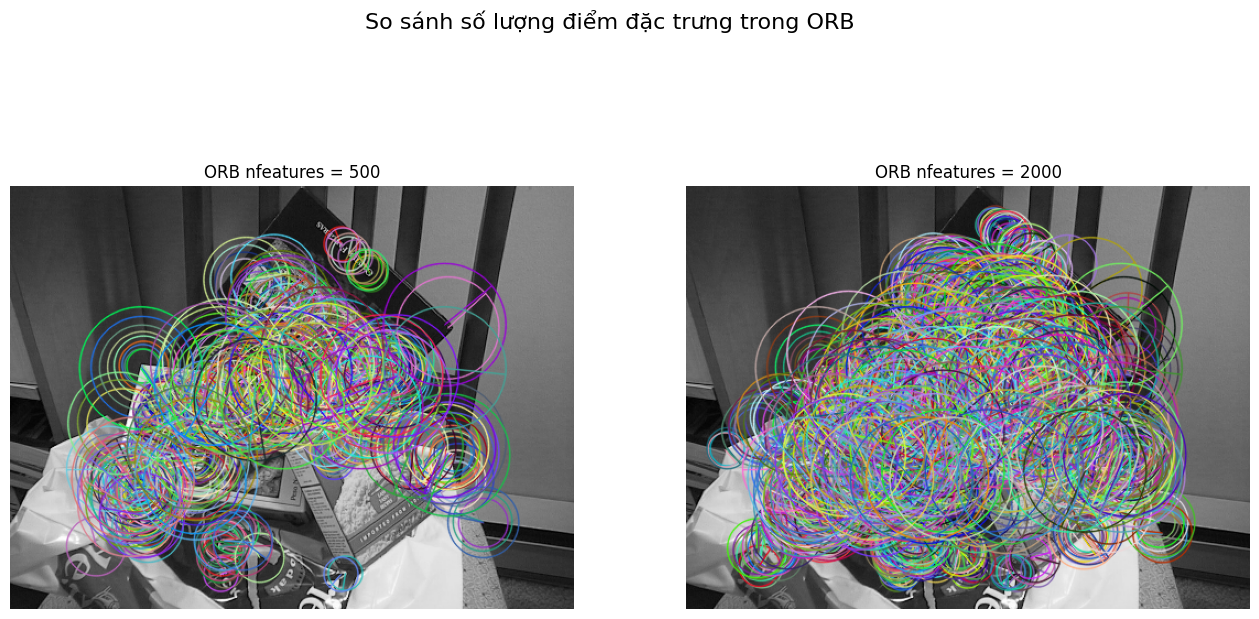

In [6]:
# Thay thế SURF bằng ORB (Oriented FAST and Rotated BRIEF)
# Khởi tạo đối tượng ORB với số lượng điểm tối đa khác nhau để so sánh
orb_500 = cv2.ORB_create(nfeatures=500)
orb_2000 = cv2.ORB_create(nfeatures=2000)

# Trích xuất Keypoint và tính toán Descriptor bằng ORB
kp_orb500, des_orb500 = orb_500.detectAndCompute(gray_scene, None)
kp_orb2000, des_orb2000 = orb_2000.detectAndCompute(gray_scene, None)

# Gán lại biến để các cell sau không bị lỗi logic (sử dụng kết quả của orb_2000)
kp_surf5000 = kp_orb2000
des_surf5000 = des_orb2000

print(f"Số lượng Keypoint với ORB (n=500): {len(kp_orb500)}")
print(f"Số lượng Keypoint với ORB (n=2000): {len(kp_orb2000)}")

# Vẽ keypoint lên ảnh để trực quan hóa
img_orb500 = cv2.drawKeypoints(img_scene, kp_orb500, None,
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_orb2000 = cv2.drawKeypoints(img_scene, kp_orb2000, None,
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

imshow_multiple('So sánh số lượng điểm đặc trưng trong ORB',
                [img_orb500, img_orb2000],
                ['ORB nfeatures = 500', 'ORB nfeatures = 2000'])

#### 2.2 Phân tích Vector Mô tả SURF (64 chiều)

Để tăng tốc độ tính toán cho các ứng dụng thời gian thực, SURF đã tối giản vector mô tả. Thay vì chia thành 16 ô với 8 hướng gradient như SIFT (tạo ra 128 chiều), SURF chia vùng ảnh thành $4 \times 4$ ô, nhưng bên trong mỗi ô chỉ tính toán 4 giá trị dựa trên **Haar-wavelet**: tổng đáp ứng theo hướng ngang ($\sum d_x$), tổng đáp ứng dọc ($\sum d_y$) và tổng giá trị tuyệt đối của chúng ($\sum |d_x|, \sum |d_y|$). Nhờ vậy, kích thước vector giảm đi một nửa.

Kích thước ma trận Descriptor ORB: (1999, 32)

Thông tin Keypoint #0 (ORB):
 - Tọa độ (x, y): (280.0, 33.0)
 - Tỷ lệ (size): 31.00
 - Điểm phản hồi (response): 0.00

Vector mô tả ORB (Thường là 32 chiều - Binary):
[ 41  53  19  65  65  93  34   8 121  72 106  72 218  81  12 180 144  28
  98  40   1  48 177  66  39 156   0   6  74   2  67 164]


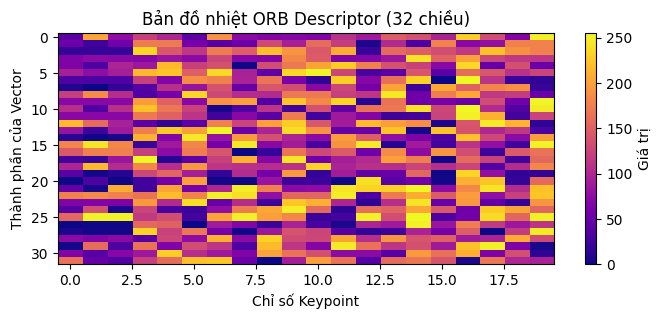

In [7]:
# Phân tích Descriptor của ORB (32 chiều - nhị phân)
print("Kích thước ma trận Descriptor ORB:", des_surf5000.shape)

if len(kp_surf5000) > 0:
    first_kp_orb = kp_surf5000[0]
    first_des_orb = des_surf5000[0]

    print(f"\nThông tin Keypoint #0 (ORB):")
    print(f" - Tọa độ (x, y): {first_kp_orb.pt}")
    print(f" - Tỷ lệ (size): {first_kp_orb.size:.2f}")
    print(f" - Điểm phản hồi (response): {first_kp_orb.response:.2f}")

    print(f"\nVector mô tả ORB (Thường là 32 chiều - Binary):")
    print(first_des_orb)

    # Hiển thị trực quan Descriptor ORB dưới dạng bản đồ nhiệt
    plt.figure(figsize=(8, 3))
    num_vec = min(20, des_surf5000.shape[0])
    plt.imshow(des_surf5000[:num_vec].T, cmap='plasma', aspect='auto')
    plt.title('Bản đồ nhiệt ORB Descriptor (32 chiều)')
    plt.xlabel('Chỉ số Keypoint')
    plt.ylabel('Thành phần của Vector')
    plt.colorbar(label='Giá trị')
    plt.show()
else:
    print("Không tìm thấy điểm đặc trưng nào.")

*Gợi ý thảo luận:* Giảng viên có thể yêu cầu sinh viên chạy cả hai đoạn code SIFT (từ Phần 1) và SURF (Phần 2) bằng module `time` trong Python để đo lường và so sánh thực tế thời gian thực thi của hàm `detectAndCompute` trên những bức ảnh lớn.

# BÀI TẬP

### Chủ đề 1: Thuật toán SIFT và Tính Bất biến (Invariance)

**Bài tập 1: Trực quan hóa Keypoint với Tỷ lệ và Hướng**
*   **Yêu cầu:** Trích xuất các điểm đặc trưng SIFT từ một bức ảnh và vẽ chúng lên ảnh gốc, sao cho thể hiện rõ quy mô (scale) và hướng (orientation) của từng điểm.
*   **Hướng dẫn:**
    *   Sử dụng `cv2.SIFT_create()` và gọi hàm `.detectAndCompute()` để lấy `keypoints`.
    *   Vẽ các điểm này bằng hàm `cv2.drawKeypoints` và bắt buộc bật cờ `cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS`.
    *   *Nhận xét:* Sinh viên cần quan sát các vòng tròn được vẽ ra: độ lớn của vòng tròn thể hiện tỷ lệ $\sigma$ nơi keypoint đạt cực trị ổn định, còn bán kính bên trong vòng tròn biểu diễn hướng chính $\theta$ của cấu trúc gradient.

**Bài tập 2: Kiểm chứng tính bất biến với phép xoay (Rotation Invariance)**
*   **Yêu cầu:** Xoay bức ảnh mẫu đi một góc (ví dụ: 30 độ), sau đó trích xuất SIFT và kiểm chứng xem các điểm đặc trưng có bị thay đổi không.
*   **Hướng dẫn:**
    *   Dùng `cv2.getRotationMatrix2D` và `cv2.warpAffine` để tạo ra một ảnh đã xoay từ ảnh gốc.
    *   Chạy thuật toán SIFT trên cả ảnh gốc và ảnh xoay.
    *   *Phân tích:* So sánh thuộc tính `angle` (hướng) của một keypoint tương ứng trên hai ảnh. Các em sẽ thấy góc lệch giữa chúng đúng bằng góc các em đã xoay ảnh, chứng minh cơ chế gán hướng chính giúp SIFT bất biến với phép xoay.

**Bài tập 3: Khảo sát cơ chế loại bỏ cạnh (Edge Threshold)**
*   **Yêu cầu:** Thay đổi tham số `edgeThreshold` trong quá trình khởi tạo SIFT để quan sát sự biến mất của các điểm đặc trưng nằm dọc theo đường biên.
*   **Hướng dẫn:**
    *   Hàm `cv2.SIFT_create()` có tham số mặc định `edgeThreshold=10`. Hãy khởi tạo một đối tượng SIFT khác với `edgeThreshold=5`.
    *   Chạy trích xuất và đếm số lượng keypoints.
    *   *Nhận xét:* Tham số này sử dụng ma trận Hessian để loại bỏ các điểm có độ cong lớn theo một hướng nhưng nhỏ theo hướng vuông góc (đặc điểm của cạnh). Ngưỡng càng nhỏ, bộ lọc càng khắt khe và các điểm nằm trên cạnh sẽ bị loại bỏ càng nhiều.

### Chủ đề 2: Phân tích Vector Mô tả SIFT (SIFT Descriptor)

**Bài tập 4: Giải mã Vector SIFT 128 chiều**
*   **Yêu cầu:** Trích xuất mảng `descriptors` và in ra màn hình cấu trúc cũng như giá trị của một vector mô tả SIFT bất kỳ.
*   **Hướng dẫn:**
    *   Lấy vector đầu tiên `descriptors`. In ra thuộc tính `.shape` để xác nhận nó có chính xác 128 chiều.
    *   *Thảo luận:* Hãy in bình luận vào code giải thích nguồn gốc của con số 128. Nó xuất phát từ việc SIFT xét vùng lân cận $16 \times 16$ pixel, chia làm 16 ô con (mỗi ô $4 \times 4$), trong mỗi ô tính một biểu đồ gradient gồm 8 hướng ($16 \times 8 = 128$).

**Bài tập 5: Khảo sát tính bất biến với chiếu sáng (Illumination Invariance)**
*   **Yêu cầu:** Biến đổi độ sáng toàn cục của ảnh và kiểm tra xem vector SIFT 128 chiều có thay đổi hay không.
*   **Hướng dẫn:**
    *   Lấy ảnh xám cộng thêm một hằng số (ví dụ: +50 độ sáng) bằng hàm `cv2.add()`.
    *   Trích xuất lại vector SIFT của một điểm keypoint không đổi.
    *   *Nhận xét:* In hai vector ra và so sánh. Sinh viên sẽ thấy các giá trị gần như tương đồng hoàn hảo. Đó là nhờ bước hậu xử lý: vector 128 chiều đã được chuẩn hóa về độ dài đơn vị (unit length) để triệt tiêu ảnh hưởng của cường độ sáng tuyến tính.

### Chủ đề 3: Thuật toán SURF và Ngưỡng Hessian

**Bài tập 6: Trực quan hóa điểm đặc trưng SURF**
*   **Yêu cầu:** Khởi tạo thuật toán SURF, trích xuất điểm đặc trưng và vẽ lên ảnh giống như đã làm với SIFT.
*   **Hướng dẫn:**
    *   Sử dụng hàm `cv2.xfeatures2d.SURF_create()` (Lưu ý: yêu cầu cài đặt `opencv-contrib-python`).
    *   Chạy hàm `detectAndCompute` và dùng `cv2.drawKeypoints` với cờ `DRAW_RICH_KEYPOINTS` để vẽ các điểm.

**Bài tập 7: Điều khiển số lượng đốm (Blob) bằng Hessian Threshold**
*   **Yêu cầu:** Thử nghiệm trích xuất SURF với 3 giá trị ngưỡng Hessian khác nhau để so sánh số lượng keypoint trả về.
*   **Hướng dẫn:**
    *   Tạo 3 đối tượng SURF với `hessianThreshold` lần lượt là 400, 2000, và 5000.
    *   Đếm độ dài mảng `keypoints` cho từng trường hợp.
    *   *Nhận xét:* SURF dùng định thức ma trận Hessian để tìm cấu trúc dạng đốm (blob). Ngưỡng Hessian càng cao, số lượng điểm giữ lại càng ít, nhưng chúng sẽ là những điểm có chất lượng và tính ổn định tốt nhất.

### Chủ đề 4: Phân tích SURF Descriptor & Tối ưu Tốc độ

**Bài tập 8: Khảo sát Vector mô tả SURF 64 chiều**
*   **Yêu cầu:** Khảo sát dung lượng và thành phần của bộ mô tả SURF so với SIFT.
*   **Hướng dẫn:**
    *   In ra `.shape` của một vector `descriptors` thu được từ SURF. Khẳng định nó chỉ có kích thước là 64.
    *   *Thảo luận:* Trình bày lý do tại sao kích thước giảm một nửa. SURF chỉ tính 4 giá trị dựa trên Haar-wavelet ($\sum dx, \sum dy, \sum |dx|, \sum |dy|$) trong 16 ô con thay vì 8 hướng gradient như SIFT.

**Bài tập 9: Đo lường và So sánh tốc độ thực thi (Speed Test)**
*   **Yêu cầu:** Đo thời gian chạy thực tế của SIFT và SURF trên cùng một bức ảnh có độ phân giải cao.
*   **Hướng dẫn:**
    *   Import thư viện `time`. Đặt `start_time = time.time()` ngay trước hàm `.detectAndCompute()` và tính khoảng thời gian chênh lệch sau khi hàm chạy xong.
    *   Thực hiện tương tự cho cả SIFT và SURF.
    *   *Phân tích:* Sinh viên sẽ thấy SURF xử lý nhanh hơn rất nhiều (gấp 3-10 lần). Hãy giải thích rằng tốc độ này có được là nhờ SURF sử dụng **Ảnh tích phân (Integral Images)** kết hợp cùng bộ lọc Box để xấp xỉ đạo hàm, thay vì thực hiện phép tích chập Gaussian nặng nề như SIFT.

### Chủ đề 5: Tổng hợp và Ứng dụng

**Bài tập 10: Xây dựng hàm trích xuất tự động chọn lọc**
*   **Yêu cầu:** Viết một hàm Python gom nhóm toàn bộ quy trình, cho phép người dùng truyền vào tham số để chọn thuật toán (SIFT/SURF) và giới hạn số lượng điểm tốt nhất muốn vẽ.
*   **Hướng dẫn:**
    *   Viết hàm `def extract_and_plot(image, method='SIFT', n_best=50):`
    *   Sử dụng lệnh `if/elif` để khởi tạo thuật toán tương ứng.
    *   Lấy ra danh sách `keypoints`. Để lọc ra `n_best` điểm, hãy sắp xếp list `keypoints` dựa trên thuộc tính `response` (độ mạnh của điểm phản hồi) theo thứ tự giảm dần.
    *   Vẽ `n_best` điểm này lên ảnh và hiển thị kết quả bằng Matplotlib.